In [1]:
# Importing necessary libraries
# Data based on https://www.youtube.com/watch?v=k8yIvVFCguA

from stoneforge.pseudo_wells import anadrill_siliciclastic, color_codes, lithology_generator
from stoneforge.vis import plotwell
import pandas as pd
import numpy as np

In [2]:
# Empty function returns available facies

anadrill_siliciclastic()

0 shale
1 clean_sandstone with gas
2 clean_sandstone with oil
3 clean_sandstone with brine
4 feldspatic sandstone
5 unconsolidated sandstone with fresh water
6 organic shale
7 siltite
8 dirty sandstone with brine


In [7]:
markov_chain = np.array(
    [[0.93, 0.07, 0.00, 0.00], # Folhelho
    [0.02, 0.97, 0.01, 0.00], # Arenito
    [0.05, 0.10, 0.85, 0.00], # Arenito arcoseo
    [0.00, 0.00, 0.00, 0.00]] # Arenito sujo
    )

litho_ref = lithology_generator.simple(markov_chain,
    lithology_code  = [0,3,4,8],
    sampling = 1200,
    initial_state = 0
)

In [8]:
from itertools import groupby

values = []
counts = []

for value, group in groupby(litho_ref):
    values.append(value)
    counts.append(len(list(group)))

result = (values, counts)

print(len(result[0]))
print(len(result[1]))

48
48


In [21]:
# Define facies and sampling structure

well1,units1 = anadrill_siliciclastic(result, top = 800.0, bottom = 2000.0, step=0.25, random_state=False)

data1 = pd.DataFrame.from_dict(well1)

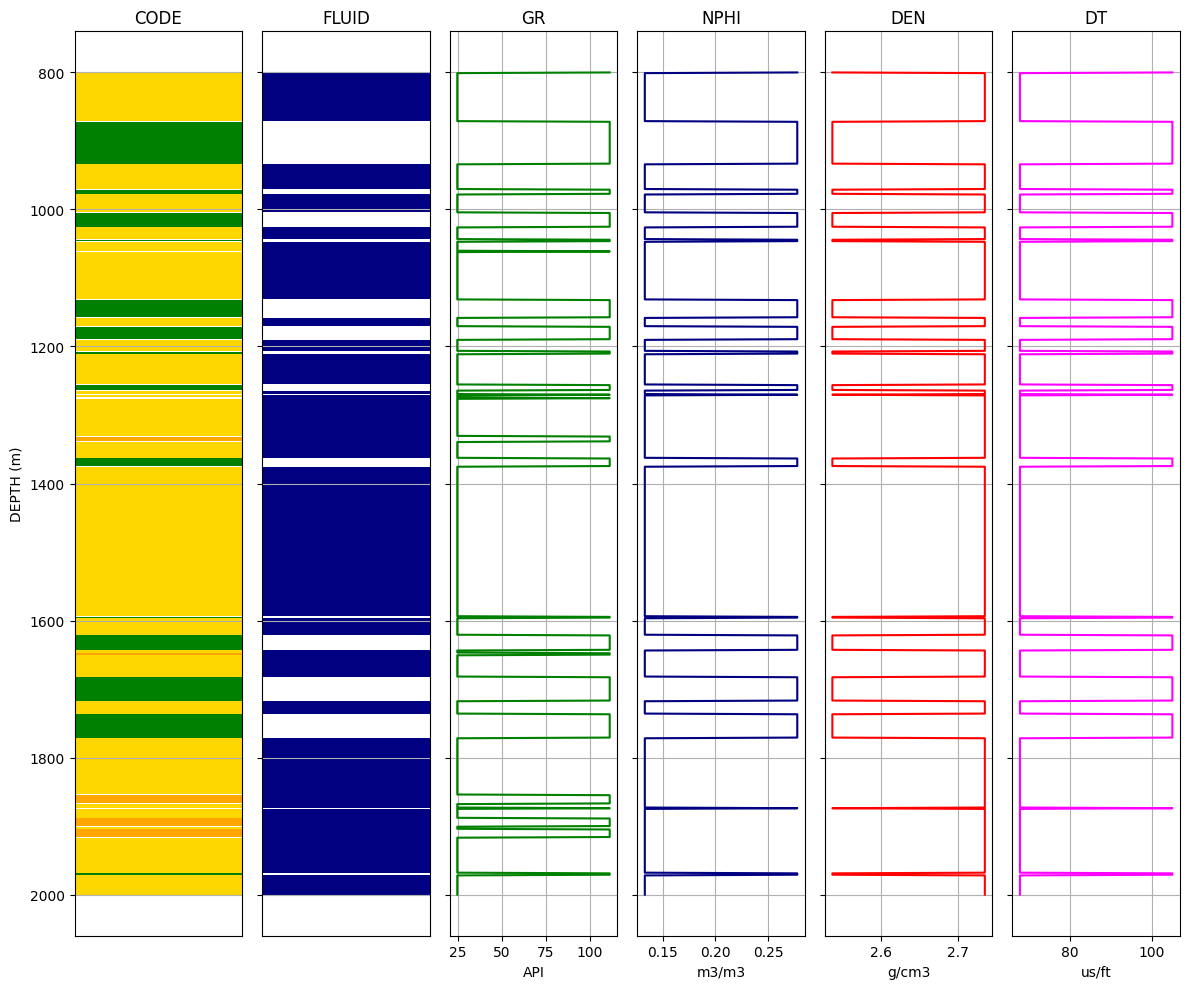

In [22]:
# Define curve and variables to plotting
# plotting data

curves = ['GR','NPHI', 'DEN', 'DT']
units2 = []
for c in curves:
    units2.append(units1[c])

color = ["green","navy","red","magenta"]

lito, fluid = color_codes()

pw = plotwell(data1, "DEPTH", curves, color, units2)
pw.facies("CODE",lito)
pw.facies("FLUID",fluid)
pw.show()

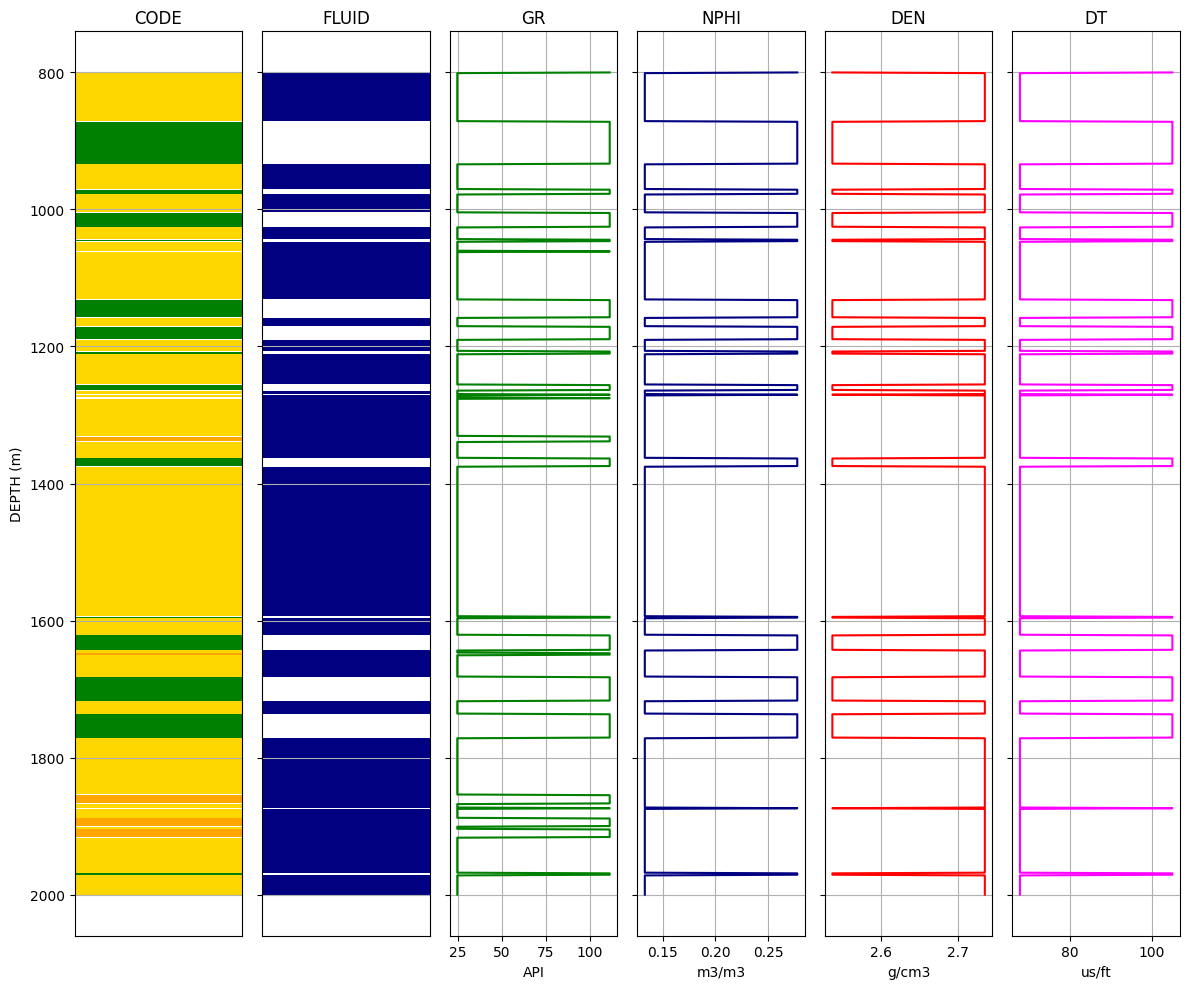

In [25]:
well2,units2 = anadrill_siliciclastic(result, top = 800.0, bottom = 2000.0, step=0.10, random_state=False)
data2 = pd.DataFrame.from_dict(well2)

curves = ['GR','NPHI', 'DEN', 'DT']
units3 = []
for c in curves:
    units3.append(units2[c])

color = ["green","navy","red","magenta"]

lito, fluid = color_codes()

pw = plotwell(data2, "DEPTH", curves, color, units3)
pw.facies("CODE",lito)
pw.facies("FLUID",fluid)
pw.show()

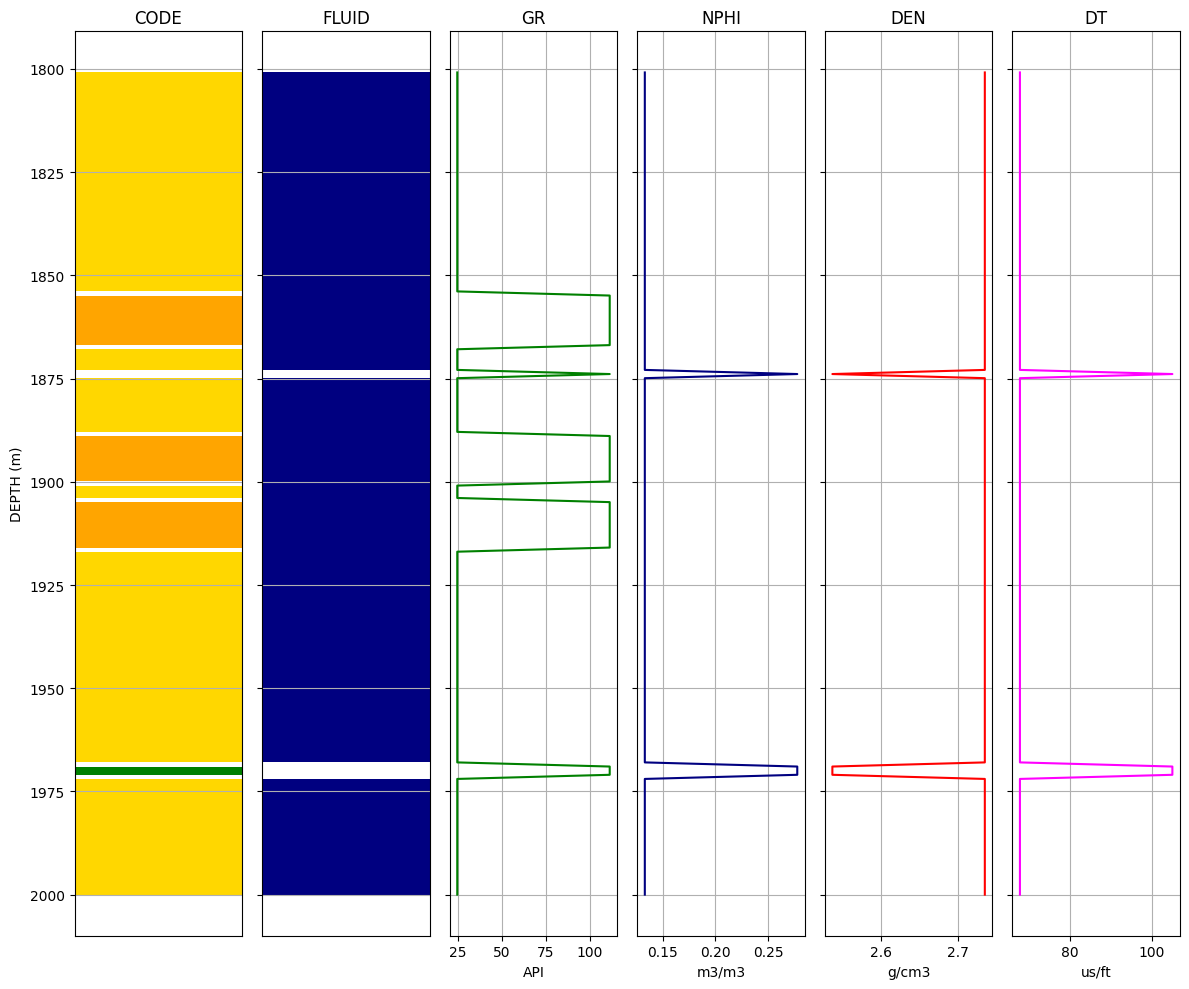

In [28]:

subd_data2 = data2[(data2['DEPTH'] >= 1800) & (data2['DEPTH'] <= 2000)]
subd_data2

pw = plotwell(subd_data2, "DEPTH", curves, color, units3)
pw.facies("CODE",lito)
pw.facies("FLUID",fluid)
pw.show()

In [52]:
litho_ref2 = lithology_generator.simple(markov_chain,
    lithology_code  = [0,3,4,8],
    sampling = 1200,
    initial_state = 3,
    seed_value = 35
)

set(litho_ref2)

{0, 3, 4}

In [53]:
values = []
counts = []

for value, group in groupby(litho_ref2):
    values.append(value)
    counts.append(len(list(group)))
    

result_b = (values, counts)

print(len(result_b[0]))
print(len(result_b[1]))


68
68


In [58]:
subd_data2

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
1000,1800.834028,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1001,1801.834862,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1002,1802.835696,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1003,1803.836530,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1004,1804.837364,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
1195,1995.996664,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1196,1996.997498,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1197,1997.998332,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1198,1998.999166,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine


In [56]:
well3,units3 = anadrill_siliciclastic(result_b, top = 2000, bottom = 2600.0, step=0.10, random_state=False)
data3 = pd.DataFrame.from_dict(well3)
data3 = data3.iloc[1:]
data3

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
1,2000.500417,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
2,2001.000834,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
3,2001.501251,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
4,2002.001668,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
5,2002.502085,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
1195,2597.998332,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1196,2598.498749,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1197,2598.999166,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1198,2599.499583,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine


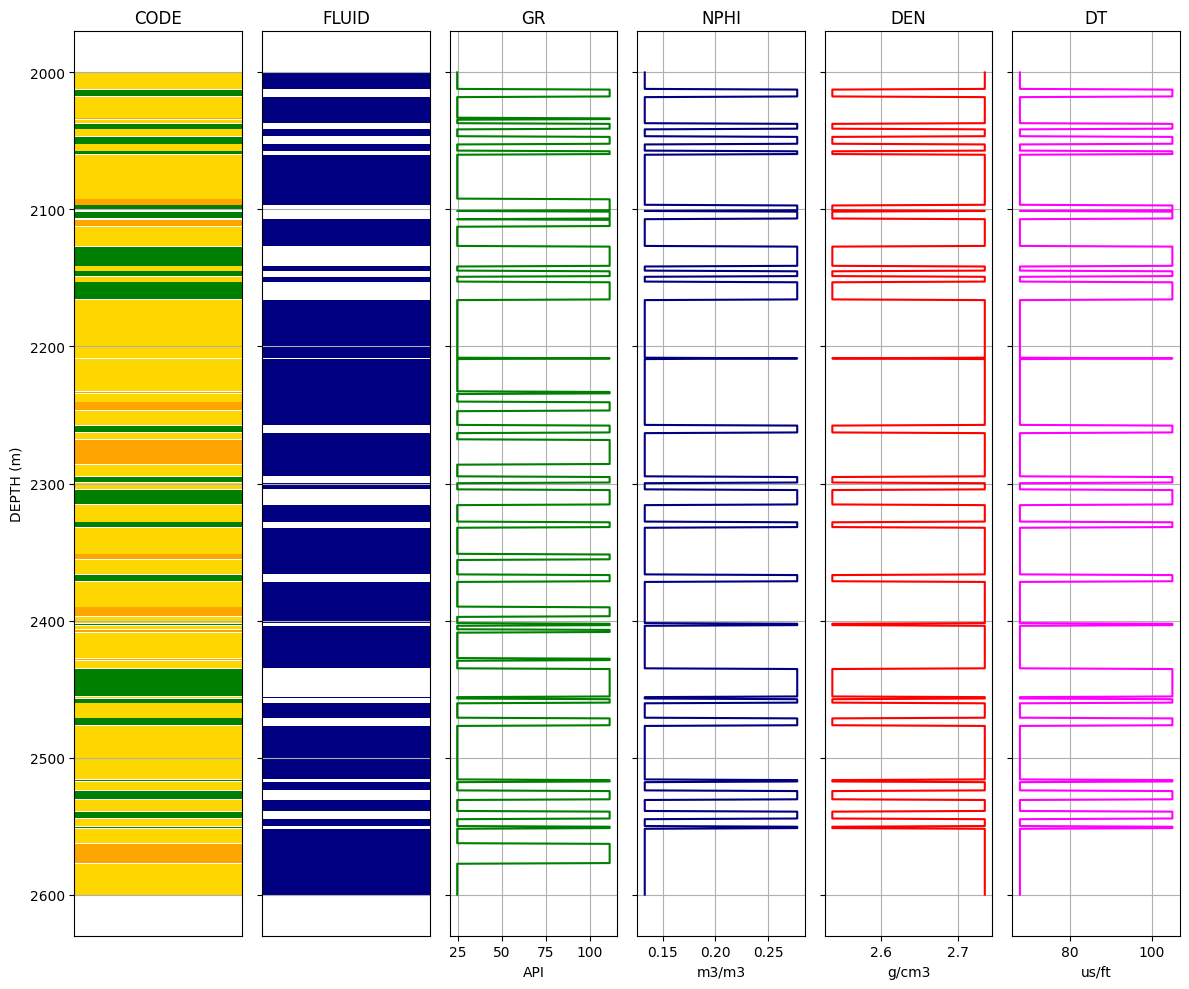

In [55]:
curves = ['GR','NPHI', 'DEN', 'DT']
units4 = []
for c in curves:
    units4.append(units3[c])

color = ["green","navy","red","magenta"]

lito1, fluid1 = color_codes()

pw = plotwell(data3, "DEPTH", curves, color, units4)
pw.facies("CODE",lito1)
pw.facies("FLUID",fluid1)
pw.show()

In [59]:
data_b = pd.concat([subd_data2, data3], ignore_index=True)
data_b

,DEPTH,GR,RES,NPHI,DEN,DT,CODE,ROCK,FLUID
0,1800.834028,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1,1801.834862,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
2,1802.835696,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
3,1803.836530,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
4,1804.837364,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
...,...,...,...,...,...,...,...,...,...
1394,2597.998332,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1395,2598.498749,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1396,2598.999166,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine
1397,2599.499583,24.566474,0.903932,0.133107,2.734104,67.935223,49,clean_sandstone,brine


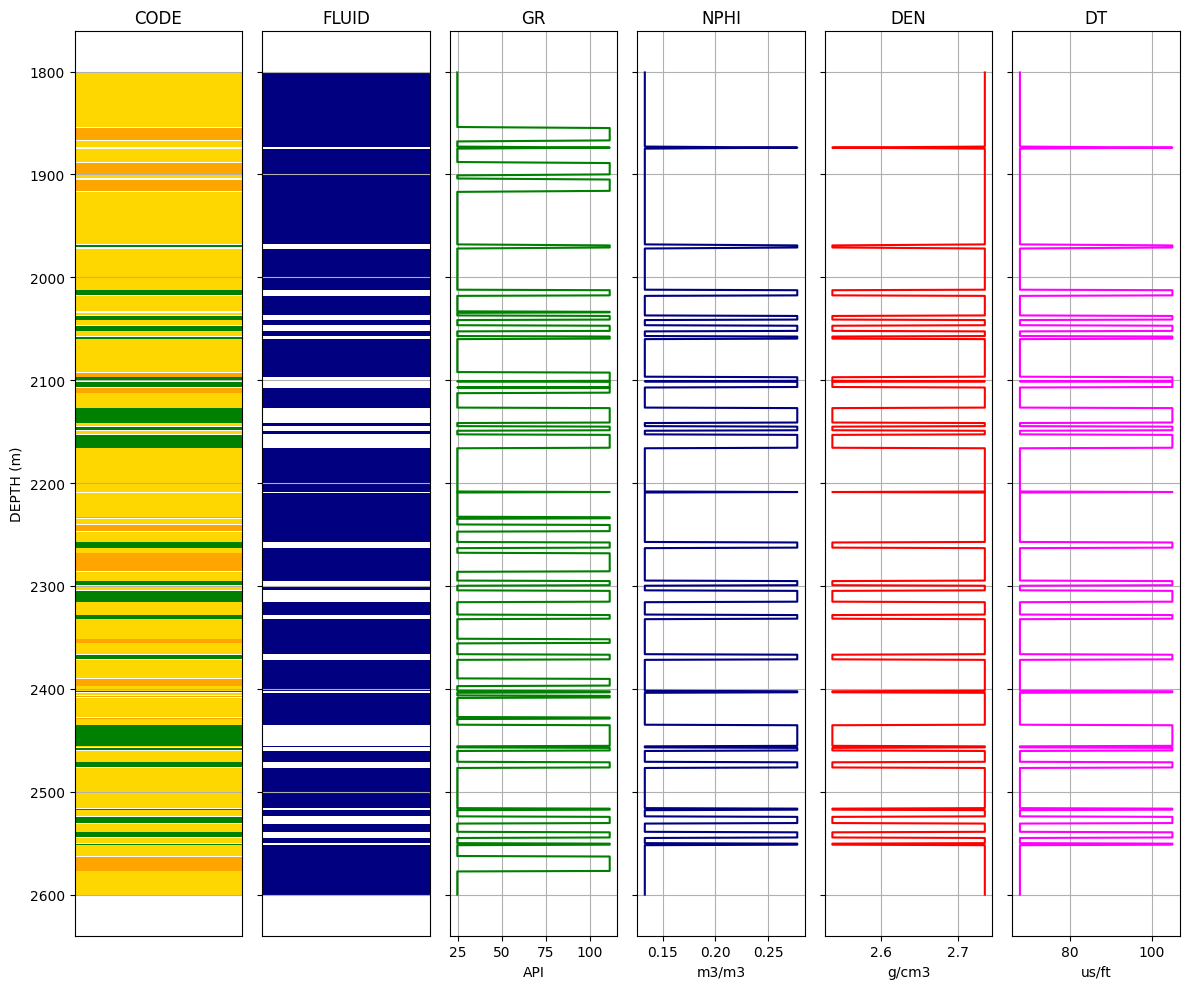

In [60]:
curves = ['GR','NPHI', 'DEN', 'DT']
units5 = []
for c in curves:
    units5.append(units3[c])

color = ["green","navy","red","magenta"]

lito1, fluid1 = color_codes()

pw = plotwell(data_b, "DEPTH", curves, color, units5)
pw.facies("CODE",lito1)
pw.facies("FLUID",fluid1)
pw.show()